## 0. Honour Code

##### I ACCEPT THE HONOUR CODE

In [1]:
!pip install dp-accounting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.5/131.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: attrs
    Found existing installation: attrs 25.4.0
    Uninstalling attrs-25.4.0:
      Successfully uninstalled attrs-25.4.0


In [2]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.func import functional_call, grad, vmap
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize as opt
from dp_accounting import dp_event as event
from dp_accounting.rdp import rdp_privacy_accountant as rdp

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

---

## 1. Batch Sizes in Private Optimization: Signal-to-noise ratio

In [ ]:
def get_noise_multiplier(target_epsilon, target_delta, sampling, step):
    RDP_ORDERS = (
        [1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0, 4.5]
        + list(range(5, 64))
        + [128, 256, 512]
    )
    def objective(noise_multiplier):
        accountant = rdp.RdpAccountant(RDP_ORDERS)
        dpevent = event.SelfComposedDpEvent(
            event.PoissonSampledDpEvent(
                sampling, event.GaussianDpEvent(noise_multiplier)
            ),
            step,
        )
        accountant.compose(dpevent)
        eps = accountant.get_epsilon(target_delta)
        return eps - target_epsilon

    optimal_noise = opt.brentq(objective, 1e-6, 1000)
    return optimal_noise

In [4]:
n = 60000
delta = 1/(n**1.1)
target_epsilons = [2, 8, 32, 128]
num_steps = 2400
batch_sizes = np.array([2**i for i in range(6, 14)])
signal_to_noise_ratios = {}

for target_epsilon in target_epsilons:
    signal_to_noise_ratios[target_epsilon] = []
    for batch in batch_sizes:
        noise_multiplier = get_noise_multiplier(target_epsilon, delta, sampling=batch/n, step=num_steps)
        signal_to_noise_ratios[target_epsilon].append(noise_multiplier/batch)

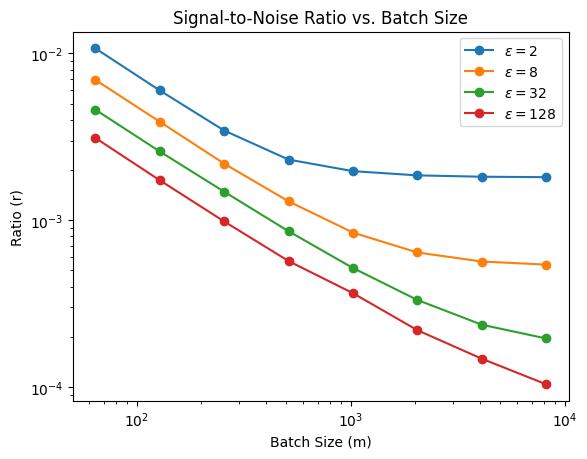

In [5]:
for target_epsilon in target_epsilons:
    plt.plot(batch_sizes, signal_to_noise_ratios[target_epsilon], marker='o', label=fr'$\epsilon={target_epsilon}$')

plt.xlabel('Batch Size (m)')
plt.ylabel('Ratio (r)')
plt.title('Signal-to-Noise Ratio vs. Batch Size')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

#### Q1.

In [ ]:
for target_epsilon in target_epsilons:
    log_log_slope = np.diff(np.log(signal_to_noise_ratios[target_epsilon])) / np.diff(np.log(batch_sizes))
    avg_slope = np.mean(log_log_slope[:3])
    print(f"Estimated slope (log-log) with linear decrease for epsilon = {target_epsilon}: {avg_slope:.2f}")


Estimated slope (log-log) with linear decrease for epsilon = 2: -0.74
Estimated slope (log-log) with linear decrease for epsilon = 8: -0.81
Estimated slope (log-log) with linear decrease for epsilon = 32: -0.81
Estimated slope (log-log) with linear decrease for epsilon = 128: -0.82


#### Q2.

In [7]:
for target_epsilon in target_epsilons:
    saturation_m = None
    for i in range(1, len(signal_to_noise_ratios[target_epsilon])):
        dec_r = signal_to_noise_ratios[target_epsilon][i] / signal_to_noise_ratios[target_epsilon][i-1]
        if dec_r > 0.95:
            saturation_m = batch_sizes[i]
            break
    if saturation_m:
        print(f"Estimated saturation batch size for epsilon = {target_epsilon}: {saturation_m}")
    else:
        print(f"Saturation for epsilon = {target_epsilon} happens beyond batch size {batch_sizes[-1]}")

Estimated saturation batch size for epsilon = 2: 4096
Estimated saturation batch size for epsilon = 8: 8192
Saturation for epsilon = 32 happens beyond batch size 8192
Saturation for epsilon = 128 happens beyond batch size 8192


---

## 2. DP-SGD Implementation: Part 1

In [8]:
train_dataset = datasets.MNIST(root="./data", train=True, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, download=True)

X_train, y_train = train_dataset.data, train_dataset.targets.long()
X_test, y_test = test_dataset.data, test_dataset.targets.long()

X_train = X_train.reshape(X_train.shape[0], -1).float() / 256
X_test = X_test.reshape(X_test.shape[0], -1).float() / 256

print(f"Train images shape: {X_train.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.70MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


Train images shape: torch.Size([60000, 784])
Train labels shape: torch.Size([60000])
Test images shape: torch.Size([10000, 784])
Test labels shape: torch.Size([10000])


In [9]:
class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden = torch.nn.Linear(input_size, hidden_size)
        self.output = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = self.output(x)
        return x


model = MLP(input_size=28*28, hidden_size=100, output_size=10)
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

hidden.weight: torch.Size([100, 784])
hidden.bias: torch.Size([100])
output.weight: torch.Size([10, 100])
output.bias: torch.Size([10])


In [ ]:
def dp_sgd(model: nn.Module, train_data, labels, batch_size, learning_rate, num_iterations, noise_multiplier, clip_norm=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    params = dict(model.named_parameters())
    buffers = dict(model.named_buffers())

    criterion = nn.CrossEntropyLoss()
    num_samples = len(labels)
    
    def loss_fn(p, b, x, y):
        x = x.unsqueeze(0)
        y = y.unsqueeze(0)
        logits = functional_call(model, (p, b), (x,))
        loss = criterion(logits, y)
        return loss.squeeze()
    
    per_ex_grad_fn = vmap(grad(loss_fn, argnums=0), in_dims=(None, None, 0, 0))

    def gradient_norm(grads: dict[str, torch.Tensor]):
        grad_norm = torch.stack([g.view(batch_size, -1).norm(dim=1) for g in grads.values()]).norm(dim=0)
        return grad_norm

    def clip_gradients(grads: dict[str, torch.Tensor], clip_norm: float):
        grad_norm = gradient_norm(grads)
        clip_coef = torch.clamp(clip_norm / (grad_norm + 1e-6), max=1.0)

        clipped_grads = {}
        for k, v in grads.items():
            broadcast_shape = [-1] + [1] * (v.dim() - 1)
            clipped_grads[k] = v * clip_coef.view(broadcast_shape)
        return clipped_grads

    for itr in range(num_iterations):
        batch_indices = np.random.choice(num_samples, size=batch_size, replace=False)
        x_batch = train_data[batch_indices].to(device)
        y_batch = labels[batch_indices].to(device)

        grads_per_ex = per_ex_grad_fn(params, buffers, x_batch, y_batch)

        grads_clipped = clip_gradients(grads_per_ex, clip_norm)

        summed_grads = [torch.sum(g, dim=0) for g in grads_clipped.values()]
        noisy_grads = [g + torch.randn_like(g) * noise_multiplier * clip_norm for g in summed_grads]
        avg_grads = [g / batch_size for g in noisy_grads]

        with torch.no_grad():
            for param, gradient in zip(params.values(), avg_grads):
                param -= learning_rate * gradient

In [ ]:
# Copied function from previous cell for use in next cell
def get_noise_multiplier(target_epsilon, target_delta, sampling, step):
    RDP_ORDERS = (
        [1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0, 4.5]
        + list(range(5, 64))
        + [128, 256, 512]
    )
    def objective(noise_multiplier):
        accountant = rdp.RdpAccountant(RDP_ORDERS)
        dpevent = event.SelfComposedDpEvent(
            event.PoissonSampledDpEvent(
                sampling, event.GaussianDpEvent(noise_multiplier)
            ),
            step,
        )
        accountant.compose(dpevent)
        eps = accountant.get_epsilon(target_delta)
        return eps - target_epsilon

    optimal_noise = opt.brentq(objective, 1e-6, 1000)
    return optimal_noise

In [ ]:
def evaluate_model(model: nn.Module, test_data, test_labels, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct = 0
    num_samples = len(test_labels)


    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            x_batch = test_data[i:i+batch_size].to(device)
            y_batch = test_labels[i:i+batch_size].to(device)
        
            outputs = model(x_batch)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == y_batch).sum().item()

    return correct / num_samples

In [13]:
n = X_train.shape[0]
batch_size = 100
num_itr = 2400
delta = 1/(n**1.1)
target_epsilon = 8
noise_multiplier = get_noise_multiplier(target_epsilon, delta, sampling=batch_size/n, step=num_itr)
clip_norm = 1.0
learning_rates = [0.01, 0.1, 1, 10]
for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    model = MLP(input_size=28*28, hidden_size=100, output_size=10)
    dp_sgd(model, X_train, y_train, batch_size, lr, num_itr, noise_multiplier, clip_norm)
    accuracy = evaluate_model(model, X_test, y_test, batch_size)
    print(f"Test Accuracy with learning rate {lr}: {accuracy:.4f}\n")

Training with learning rate: 0.01
Test Accuracy with learning rate 0.01: 0.7026

Training with learning rate: 0.1
Test Accuracy with learning rate 0.1: 0.8982

Training with learning rate: 1
Test Accuracy with learning rate 1: 0.9103

Training with learning rate: 10
Test Accuracy with learning rate 10: 0.8154



##### From the above report we can see that test accuracy is highest (0.9103) for learning rate = 1.

---

## 3. DP-SGD: Part 2

In [14]:
def dp_sgd_accum_grads(model: nn.Module, train_data, labels, batch_size, learning_rate, num_iterations, noise_multiplier, clip_norm, max_sub_batch):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    params = dict(model.named_parameters())
    buffers = dict(model.named_buffers())

    criterion = nn.CrossEntropyLoss()
    num_samples = len(labels)
    
    def loss_fn(p, b, x, y):
        x = x.unsqueeze(0)
        y = y.unsqueeze(0)
        logits = functional_call(model, (p, b), (x,))
        loss = criterion(logits, y)
        return loss.squeeze()
    
    per_ex_grad_fn = vmap(grad(loss_fn, argnums=0), in_dims=(None, None, 0, 0))

    def gradient_norm(grads: dict[str, torch.Tensor]):
        grad_norm = torch.stack([g.view(g.shape[0], -1).norm(dim=1) for g in grads.values()]).norm(dim=0)
        return grad_norm

    def clip_gradients(grads: dict[str, torch.Tensor], clip_norm: float):
        grad_norm = gradient_norm(grads)
        clip_coef = torch.clamp(clip_norm / (grad_norm + 1e-6), max=1.0)

        clipped_grads = {}
        for k, v in grads.items():
            broadcast_shape = [-1] + [1] * (v.dim() - 1)
            clipped_grads[k] = v * clip_coef.view(broadcast_shape)
        return clipped_grads

    for itr in range(num_iterations):
        batch_indices = np.random.choice(num_samples, size=batch_size, replace=False)
        x_batch = train_data[batch_indices].to(device)
        y_batch = labels[batch_indices].to(device)

        summed_grads = {k: torch.zeros_like(v) for k, v in params.items()}
        x_sub_batches = torch.split(x_batch, max_sub_batch)
        y_sub_batches = torch.split(y_batch, max_sub_batch)

        for x_sub, y_sub in zip(x_sub_batches, y_sub_batches):
            grads_per_ex = per_ex_grad_fn(params, buffers, x_sub, y_sub)
            grads_clipped = clip_gradients(grads_per_ex, clip_norm)
            for k in summed_grads:
                summed_grads[k] += torch.sum(grads_clipped[k], dim=0)

        noisy_grads = [g + torch.randn_like(g) * noise_multiplier * clip_norm for g in summed_grads.values()]
        avg_grads = [g / batch_size for g in noisy_grads]

        with torch.no_grad():
            for param, gradient in zip(params.values(), avg_grads):
                param -= learning_rate * gradient

In [15]:
n = X_train.shape[0]
batch_size = 8192 # Saturation happens around this batch size for epsilon = 8
num_itr = 2400
delta = 1/(n**1.1)
target_epsilon = 8
learning_rates = [0.1, 1, 10, 100]
clip_norm = 1.0
max_sub_batch = 1024
noise_multiplier = get_noise_multiplier(target_epsilon, delta, sampling=batch_size/n, step=num_itr)
print(f"Performing DP-SGD with accumulated gradients for batch size {batch_size} (using Heuristic in Problem 1) for epsilon = {target_epsilon}")

best_test_acc = {target_epsilon: (0, 0)} # To store best accuracy and corresponding learning rate for epsilon = 8
for lr in learning_rates:
    print(f"Training with learning rate : {lr}")
    model = MLP(input_size=28*28, hidden_size=100, output_size=10)
    dp_sgd_accum_grads(model, X_train, y_train, batch_size, lr, num_itr, noise_multiplier, clip_norm, max_sub_batch)
    accuracy = evaluate_model(model, X_test, y_test, batch_size)
    print(f"Test Accuracy with learning rate {lr}: {accuracy:.4f}\n")
    if accuracy > best_test_acc[target_epsilon][0]:
        best_test_acc[target_epsilon] = (accuracy, lr)

Performing DP-SGD with accumulated gradients for batch size 8192 (using Heuristic in Problem 1) for epsilon = 8
Training with learning rate : 0.1
Test Accuracy with learning rate 0.1: 0.8956

Training with learning rate : 1
Test Accuracy with learning rate 1: 0.9355

Training with learning rate : 10
Test Accuracy with learning rate 10: 0.9640

Training with learning rate : 100
Test Accuracy with learning rate 100: 0.8356



##### From the above results, we can see that for batch size = 8192 and target epsilon = 8, the best test accuracy (0.9640) is for learning rate = 10.

---

## 4. Privacy-Utility Tradeoffs for DP-SGD

#### For $\epsilon = 2$

In [16]:
target_epsilon = 2
n = X_train.shape[0]
batch_size = 4096 # Saturation happens around this batch size for epsilon = 2
num_itr = 2400
delta = 1/(n**1.1)
learning_rates = [0.1, 1, 10, 100]
clip_norm = 1.0
max_sub_batch = 1024
noise_multiplier = get_noise_multiplier(target_epsilon, delta, sampling=batch_size/n, step=num_itr)
print(f"Performing DP-SGD with accumulated gradients for batch size {batch_size} for epsilon = {target_epsilon}")

best_test_acc[target_epsilon] = (0, 0)
for lr in learning_rates:
    print(f"Training with learning rate : {lr}")
    model = MLP(input_size=28*28, hidden_size=100, output_size=10)
    dp_sgd_accum_grads(model, X_train, y_train, batch_size, lr, num_itr, noise_multiplier, clip_norm, max_sub_batch)
    accuracy = evaluate_model(model, X_test, y_test, batch_size)
    print(f"Test Accuracy with learning rate {lr}: {accuracy:.4f}\n")
    if accuracy > best_test_acc[target_epsilon][0]:
        best_test_acc[target_epsilon] = (accuracy, lr)

Performing DP-SGD with accumulated gradients for batch size 4096 for epsilon = 2
Training with learning rate : 0.1
Test Accuracy with learning rate 0.1: 0.8950

Training with learning rate : 1
Test Accuracy with learning rate 1: 0.9342

Training with learning rate : 10
Test Accuracy with learning rate 10: 0.9156

Training with learning rate : 100
Test Accuracy with learning rate 100: 0.7248



#### For $\epsilon = 32$

In [17]:
target_epsilon = 32
n = X_train.shape[0]
batch_size = 16384 # Saturation happens around this batch size for epsilon = 32
num_itr = 2400
delta = 1/(n**1.1)
learning_rates = [0.1, 1, 10, 100]
clip_norm = 1.0
max_sub_batch = 1024
noise_multiplier = get_noise_multiplier(target_epsilon, delta, sampling=batch_size/n, step=num_itr)
print(f"Performing DP-SGD with accumulated gradients for batch size {batch_size} for epsilon = {target_epsilon}")

best_test_acc[target_epsilon] = (0, 0)
for lr in learning_rates:
    print(f"Training with learning rate : {lr}")
    model = MLP(input_size=28*28, hidden_size=100, output_size=10)
    dp_sgd_accum_grads(model, X_train, y_train, batch_size, lr, num_itr, noise_multiplier, clip_norm, max_sub_batch)
    accuracy = evaluate_model(model, X_test, y_test, batch_size)
    print(f"Test Accuracy with learning rate {lr}: {accuracy:.4f}\n")
    if accuracy > best_test_acc[target_epsilon][0]:
        best_test_acc[target_epsilon] = (accuracy, lr)

Performing DP-SGD with accumulated gradients for batch size 16384 for epsilon = 32
Training with learning rate : 0.1
Test Accuracy with learning rate 0.1: 0.8950

Training with learning rate : 1
Test Accuracy with learning rate 1: 0.9380

Training with learning rate : 10
Test Accuracy with learning rate 10: 0.9746

Training with learning rate : 100
Test Accuracy with learning rate 100: 0.2901



In [18]:
const_batch_best_test_acc = {}
n = X_train.shape[0]
batch_size = 100
num_itr = 2400
delta = 1/(n**1.1)
clip_norm = 1.0
noise_multiplier = get_noise_multiplier(target_epsilon, delta, sampling=batch_size/n, step=num_itr)
learning_rates = [0.1, 1, 10, 100]
for target_epsilon in [2, 8, 32]:
    print(f"Performing DP-SGD for batch size {batch_size} for epsilon = {target_epsilon}")
    for lr in learning_rates:
        model = MLP(input_size=28*28, hidden_size=100, output_size=10)
        dp_sgd(model, X_train, y_train, batch_size, lr, num_itr, noise_multiplier, clip_norm)
        accuracy = evaluate_model(model, X_test, y_test, batch_size)
        print(f"Test Accuracy with learning rate {lr}: {accuracy:.4f}\n")
        if target_epsilon not in const_batch_best_test_acc or accuracy > const_batch_best_test_acc[target_epsilon][0]:
            const_batch_best_test_acc[target_epsilon] = (accuracy, lr)

Performing DP-SGD for batch size 100 for epsilon = 2
Test Accuracy with learning rate 0.1: 0.8965

Test Accuracy with learning rate 1: 0.9266

Test Accuracy with learning rate 10: 0.8674

Test Accuracy with learning rate 100: 0.4445

Performing DP-SGD for batch size 100 for epsilon = 8
Test Accuracy with learning rate 0.1: 0.8938

Test Accuracy with learning rate 1: 0.9278

Test Accuracy with learning rate 10: 0.8662

Test Accuracy with learning rate 100: 0.3593

Performing DP-SGD for batch size 100 for epsilon = 32
Test Accuracy with learning rate 0.1: 0.8946

Test Accuracy with learning rate 1: 0.9249

Test Accuracy with learning rate 10: 0.8664

Test Accuracy with learning rate 100: 0.3729



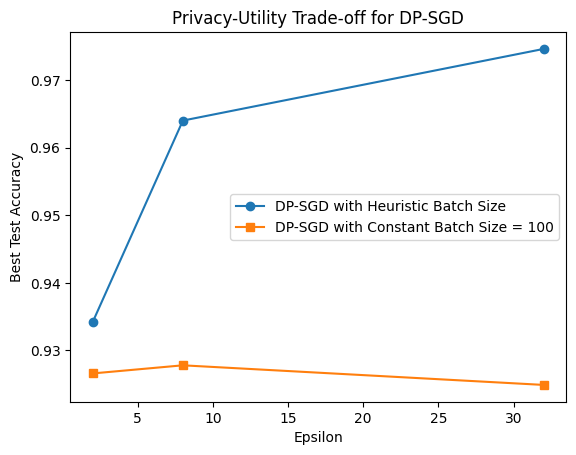

In [20]:
epsilon_l = [2, 8, 32]
best_test_acc_list = [best_test_acc[eps][0] for eps in epsilon_l]
const_batch_best_test_acc_list = [const_batch_best_test_acc[eps][0] for eps in epsilon_l]
plt.plot(epsilon_l, best_test_acc_list, marker='o', label='DP-SGD with Heuristic Batch Size')
plt.plot(epsilon_l, const_batch_best_test_acc_list, marker='s', label='DP-SGD with Constant Batch Size = 100')
plt.xlabel('Epsilon')
plt.ylabel('Best Test Accuracy')
plt.title('Privacy-Utility Trade-off for DP-SGD')
plt.legend()
plt.show()

##### We can see that the heuristic we used to determine batch size has better performance than just using a constant batch size of 100.

##### We can also note that on increasing epsilon we get better performance (utility) but our privacy guarantees weaken (weaker bounds). This shows the privacy-utility tradeoff.

---